In [1]:
import geopandas as gpd
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
EPSG = "EPSG:31256"

reduction_polygon = np.array([[3599.8874170715394,	340907.17366641754],
							  [3648.3580812379278,	340882.9493204322],
							  [3616.96347532236,	340824.96835747146],
							  [3571.3034212154816,	340861.6948829265],
							  [3599.8874170715394,	340907.17366641754]])

# import camera positions
image_meta_df = pd.read_csv("../LiDAR_kappazunder_stadtpark/Los_6A/Bild-Meta/image_meta.txt", sep="\t")
image_meta_df.head()

,trajectory_id,sensor_id,image_id,epoch_s,image_name,x_m,y_m,z_m,rx_rad,ry_rad,rz_rad
0,15767,110020,81077806,544305.54,WE1H2XH4.jpg,3708.061,340916.770,11.990,0.0,0.0,3.534082
1,15767,110020,81077807,544306.76,WE1H2XH5.jpg,3706.875,340914.002,11.903,0.0,0.0,3.545221
2,15767,110020,81077808,544308.01,WE1H2XH6.jpg,3705.571,340911.288,11.863,0.0,0.0,3.603837
3,15767,110020,81077809,544309.27,WE1H2XH7.jpg,3704.008,340908.711,11.836,0.0,0.0,3.697283
4,15767,110020,81077810,544310.42,WE1H2XH8.jpg,3702.398,340906.151,11.821,0.0,0.0,3.658704


In [3]:
image_meta_gdf = gpd.GeoDataFrame(
	image_meta_df,
	geometry=gpd.points_from_xy(image_meta_df["x_m"], image_meta_df["y_m"]),
	crs=EPSG,
)

In [4]:
image_meta_gdf[image_meta_gdf["sensor_id"] == 110021].head(20)

,trajectory_id,sensor_id,image_id,epoch_s,image_name,x_m,y_m,z_m,rx_rad,ry_rad,rz_rad,geometry
228,15767,110021,81077806,544305.54,WE1H2XH4.jpg,3708.061,340916.770,11.990,-1.570796,0.0,3.534082,POINT (3708.061 340916.77)
229,15767,110021,81077807,544306.76,WE1H2XH5.jpg,3706.875,340914.002,11.903,-1.570796,0.0,3.545221,POINT (3706.875 340914.002)
230,15767,110021,81077808,544308.01,WE1H2XH6.jpg,3705.571,340911.288,11.863,-1.570796,0.0,3.603837,POINT (3705.571 340911.288)
231,15767,110021,81077809,544309.27,WE1H2XH7.jpg,3704.008,340908.711,11.836,-1.570796,0.0,3.697283,POINT (3704.008 340908.711)
232,15767,110021,81077810,544310.42,WE1H2XH8.jpg,3702.398,340906.151,11.821,-1.570796,0.0,3.658704,POINT (3702.398 340906.151)
233,15767,110021,81077811,544311.35,WE1H2XH9.jpg,3701.007,340903.481,11.821,-1.570796,0.0,3.583103,POINT (3701.007 340903.481)
234,15767,110021,81077812,544312.26,WE1H2XHA.jpg,3699.773,340900.746,11.834,-1.570796,0.0,3.554609,POINT (3699.773 340900.746)
235,15767,110021,81077813,544313.12,WE1H2XHB.jpg,3698.521,340898.002,11.856,-1.570796,0.0,3.574189,POINT (3698.521 340898.002)
236,15767,110021,81077814,544313.96,WE1H2XHC.jpg,3697.124,340895.329,11.855,-1.570796,0.0,3.629677,POINT (3697.124 340895.329)
237,15767,110021,81077815,544314.77,WE1H2XHD.jpg,3695.596,340892.728,11.851,-1.570796,0.0,3.686755,POINT (3695.596 340892.728)


(0.0, 20.0)

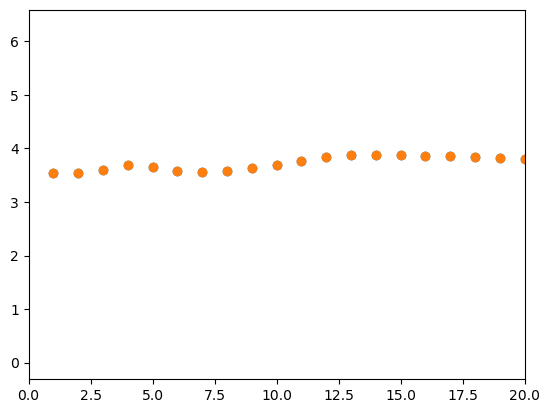

In [5]:
plt.scatter(np.arange(1, len(image_meta_gdf[image_meta_gdf["sensor_id"] == 110021]) + 1), image_meta_gdf[image_meta_gdf["sensor_id"] == 110021]["rz_rad"]) # front-facing camera
plt.scatter(np.arange(1, len(image_meta_gdf) + 1), image_meta_gdf["rz_rad"]) # up-facing camera
plt.xlim(0, 20)

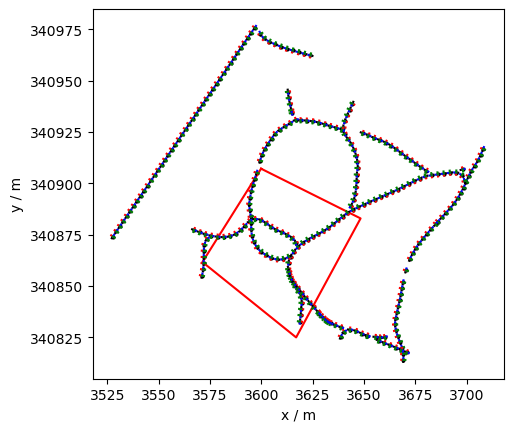

In [6]:
plt.plot(reduction_polygon[:, 0], reduction_polygon[:, 1], "r-")
dir_len = 1.
for i in range(0, len(image_meta_gdf[image_meta_gdf["sensor_id"] == 110021])):
	selection = image_meta_gdf[image_meta_gdf["sensor_id"] == 110021].iloc[i] # front-facing camera
	x, y = selection.geometry.x, selection.geometry.y
	plt.scatter(x, y, s=4, c="k")
	# Plot a small line from the camera position in the direction of the camera orientation (rz_rad)
	plt.plot(
		[x, x + dir_len * np.sin(selection.rz_rad)],
		[y, y + dir_len * np.cos(selection.rz_rad)],
		c="k",
	)
	selection = image_meta_gdf[image_meta_gdf["sensor_id"] == 110022].iloc[i] # right-racing camera (same position)
	plt.plot(
		[x, x + dir_len * np.sin(selection.rz_rad)],
		[y, y + dir_len * np.cos(selection.rz_rad)],
		c="r",
	)
	selection = image_meta_gdf[image_meta_gdf["sensor_id"] == 110023].iloc[i] # back-facing camera (same position)
	plt.plot(
		[x, x + dir_len * np.sin(selection.rz_rad)],
		[y, y + dir_len * np.cos(selection.rz_rad)],
		c="b",
	)
	selection = image_meta_gdf[image_meta_gdf["sensor_id"] == 110024].iloc[i] # left-facing camera (same position)
	plt.plot(
		[x, x + dir_len * np.sin(selection.rz_rad)],
		[y, y + dir_len * np.cos(selection.rz_rad)],
		c="g",
	)
	# Up and down work similarly, but we don't need to draw them right now

# Correct aspect ratio
plt.gca().set_aspect("equal", adjustable="box")
plt.xlabel("x / m")
plt.ylabel("y / m")
plt.show()

In [7]:
image_meta_gdf[image_meta_gdf["sensor_id"] == 110024].iloc[40:80][["sensor_id", "image_name", "x_m", "y_m", "rz_rad"]] # front-facing camera

,sensor_id,image_name,x_m,y_m,rz_rad
952,110024,WE1H2XIB.jpg,3665.499,340820.045,3.526875
953,110024,WE1H2XIC.jpg,3662.753,340821.156,3.523114
954,110024,WE1H2XID.jpg,3659.983,340822.263,3.517254
955,110024,WE1H2XIE.jpg,3657.210,340823.369,3.511206
956,110024,WE1H2XIG.jpg,3651.671,340825.627,3.526103
957,110024,WE1H2XIH.jpg,3648.927,340826.872,3.552653
958,110024,WE1H2XII.jpg,3646.157,340828.061,3.503613
959,110024,WE1H2XIJ.jpg,3643.241,340828.770,3.206006
960,110024,WE1H2XIK.jpg,3640.430,340827.750,2.564729
961,110024,WE1H2XIL.jpg,3638.736,340825.300,2.002206


In [8]:
from build_colmap_selection import *

In [9]:
image_meta_gdf = load_image_meta(IMAGE_META_PATH)
image_meta_gdf.head()

,trajectory_id,sensor_id,image_id,epoch_s,image_name,x_m,y_m,z_m,rx_rad,ry_rad,rz_rad,geometry
0,15767,110020,81077806,544305.54,WE1H2XH4.jpg,3708.061,340916.770,11.990,0.0,0.0,3.534082,POINT (3708.061 340916.77)
1,15767,110020,81077807,544306.76,WE1H2XH5.jpg,3706.875,340914.002,11.903,0.0,0.0,3.545221,POINT (3706.875 340914.002)
2,15767,110020,81077808,544308.01,WE1H2XH6.jpg,3705.571,340911.288,11.863,0.0,0.0,3.603837,POINT (3705.571 340911.288)
3,15767,110020,81077809,544309.27,WE1H2XH7.jpg,3704.008,340908.711,11.836,0.0,0.0,3.697283,POINT (3704.008 340908.711)
4,15767,110020,81077810,544310.42,WE1H2XH8.jpg,3702.398,340906.151,11.821,0.0,0.0,3.658704,POINT (3702.398 340906.151)


In [10]:
interior_df = load_interior_orientation(INTERIOR_ORIENTATION_PATH)
interior_df.head()

f:\Documents\LiDAR_kappazunder_stadpark_reduced\build_colmap_selection.py:110: ParserWarning: Length of header or names does not match length of data. This leads to a loss of data with index_col=False.
  df = pd.read_csv(path, sep="\t", index_col=False)


,sensor_id,type_projection,c_mm,psu_mm,psv_mm,pix_u,pix_v,dh_m,pitch_rad
0,110010,p,16.399,0.0046,0.0046,7130,7130,2.09,1.570796
1,110011,p,16.399,0.0046,0.0046,7130,7130,2.09,0.000000
2,110012,p,16.399,0.0046,0.0046,7130,7130,2.09,0.000000
3,110013,p,16.399,0.0046,0.0046,7130,7130,2.09,0.000000
4,110014,p,16.399,0.0046,0.0046,7130,7130,2.09,0.000000


In [11]:
fov_by_sensor = load_fov_per_sensor(INTERIOR_ORIENTATION_PATH)
fov_by_sensor

{'p': np.float64(3.1410316437868353)}

In [12]:
print(f"Loaded {len(image_meta_gdf)} image records.")
print(f"FOV by sensor (deg): "
	  f"{ {k: round(np.degrees(v),1) for k,v in fov_by_sensor.items()} }")

Loaded 1620 image records.
FOV by sensor (deg): {'p': np.float64(180.0)}


In [13]:
image_meta_gdf = select_images(
	image_meta_gdf, REDUCTION_POLYGON, fov_by_sensor, MAX_FRUSTUM_DIST
)
n_selected = image_meta_gdf["selected"].sum()
print(f"Selected {n_selected} / {len(image_meta_gdf)} images "
	  f"(frustum intersects ROI).")

plot_path = OUTPUT_DIR / "selection_preview.png"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
plot_selection(image_meta_gdf, REDUCTION_POLYGON, fov_by_sensor,
				MAX_FRUSTUM_DIST, plot_path)
print(f"Saved selection preview: {plot_path}")

Selected 477 / 1620 images (frustum intersects ROI).
Saved selection preview: colmap_export\selection_preview.png


In [14]:
selected_gdf = image_meta_gdf[image_meta_gdf["selected"]].copy()

if len(selected_gdf) == 0:
	print("No images selected -- check ROI polygon / MAX_FRUSTUM_DIST.")
else:
	# Center the scene on the selected images' centroid (in x,y; z kept
	# at the mean camera height so vertical values also stay small).
	scene_origin = (
		selected_gdf["x_m"].mean(),
		selected_gdf["y_m"].mean(),
		selected_gdf["z_m"].mean(),
	)
	print(f"Scene origin (EPSG:31256): "
			f"x={scene_origin[0]:.3f} y={scene_origin[1]:.3f} z={scene_origin[2]:.3f}")

	name_map = copy_and_rename_images(
		selected_gdf, RAW_IMAGES_ROOT, OUTPUT_IMAGES_DIR, copy=COPY_IMAGES
	)
	export_colmap(selected_gdf, interior_df, OUTPUT_SPARSE_DIR, name_map,
					scene_origin)
	print(f"\nDone. COLMAP-format export at: {OUTPUT_DIR}")
	print(f"  {OUTPUT_DIR}/images/        <- (renamed) images"
			f"{'(not copied -- COPY_IMAGES=False)' if not COPY_IMAGES else ''}")
	print(f"  {OUTPUT_DIR}/sparse/0/      <- cameras.txt, images.txt, points3D.txt")
	print(f"  {OUTPUT_DIR}/scene_origin.txt  <- offset, reuse for LiDAR PLY export")

Scene origin (EPSG:31256): x=3609.183 y=340868.814 z=12.754
Wrote colmap_export\sparse\0\cameras.txt
Wrote colmap_export\sparse\0\images.txt
Wrote colmap_export\sparse\0\points3D.txt
Wrote colmap_export\scene_origin.txt  (offset: 3609.183, 340868.814, 12.754)

Done. COLMAP-format export at: colmap_export
  colmap_export/images/        <- (renamed) images
  colmap_export/sparse/0/      <- cameras.txt, images.txt, points3D.txt
  colmap_export/scene_origin.txt  <- offset, reuse for LiDAR PLY export


In [15]:
# debug_csv_path = OUTPUT_DIR / "debug_camera_positions_qgis.csv"
# export_debug_csv_for_qgis(selected_gdf, debug_csv_path)

In [16]:
interior_df.iloc[0]

sensor_id            110010
type_projection           p
c_mm                 16.399
psu_mm               0.0046
psv_mm               0.0046
pix_u                  7130
pix_v                  7130
dh_m                   2.09
pitch_rad          1.570796
Name: 0, dtype: object

In [17]:
from laz_to_ply import *

In [22]:
5.104878 - 3.534082

1.570796

In [23]:
3.534082 - 0.392489

3.1415930000000003

In [26]:
(1.963286 - 3/2 * np.pi) % (2 * np.pi)

3.5340823267948966

In [18]:
main()

Trajektorie_15767_AoI_thin.laz: 1,059,344 points
Total merged points: 1,059,344
Voxel downsampled (0.03 m): 1,059,344 -> 989,993 points
Wrote colmap_export\points3D_init.ply (989,993 points)


In [18]:
f = open("colmap_export/scene_origin.txt", "r")
lines = f.readlines()[3:6]
scene_origin = pd.DataFrame([line.strip().split() for line in lines], columns=["axis", "value"]).values[:, 1].astype(float)
scene_origin

array([3.60918250e+03, 3.40868814e+05, 1.27537360e+01])

In [19]:
import rotation_conversion

In [22]:
rotation_conversion.__main__()

AttributeError: module 'rotation_conversion' has no attribute '__main__'

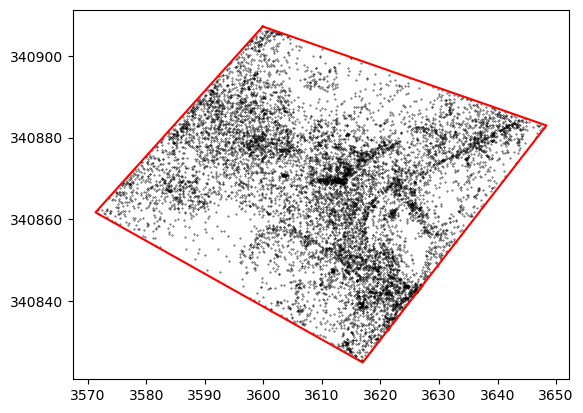

In [34]:
LAZ_PATHS = [
    "Trajektorie_15767_AoI_thin.laz",
]

point_cloud_xy = read_laz_as_arrays(LAZ_PATHS[0])[0][:, :2][::100]

plt.scatter(point_cloud_xy[:, 0], point_cloud_xy[:, 1], s=0.1, c="k")
plt.plot(reduction_polygon[:, 0], reduction_polygon[:, 1], "r-")

In [ ]:
plt.plot(reduction_polygon[:, 0], reduction_polygon[:, 1], "r-")
dir_len = 1.
for i in range(0, len(image_meta_gdf[image_meta_gdf["sensor_id"] == 110021])):
	selection = image_meta_gdf[image_meta_gdf["sensor_id"] == 110021].iloc[i] # front-facing camera
	x, y = selection.geometry.x, selection.geometry.y
	plt.scatter(x, y, s=4, c="k")
	# Plot a small line from the camera position in the direction of the camera orientation (rz_rad)
	plt.plot(
		[x, x + dir_len * np.sin(selection.rz_rad)],
		[y, y + dir_len * np.cos(selection.rz_rad)],
		c="k",
	)
	selection = image_meta_gdf[image_meta_gdf["sensor_id"] == 110022].iloc[i] # right-racing camera (same position)
	plt.plot(
		[x, x + dir_len * np.sin(selection.rz_rad)],
		[y, y + dir_len * np.cos(selection.rz_rad)],
		c="r",
	)
	selection = image_meta_gdf[image_meta_gdf["sensor_id"] == 110023].iloc[i] # back-facing camera (same position)
	plt.plot(
		[x, x + dir_len * np.sin(selection.rz_rad)],
		[y, y + dir_len * np.cos(selection.rz_rad)],
		c="b",
	)
	selection = image_meta_gdf[image_meta_gdf["sensor_id"] == 110024].iloc[i] # left-facing camera (same position)
	plt.plot(
		[x, x + dir_len * np.sin(selection.rz_rad)],
		[y, y + dir_len * np.cos(selection.rz_rad)],
		c="g",
	)
	# Up and down work similarly, but we don't need to draw them right now

# Correct aspect ratio
plt.gca().set_aspect("equal", adjustable="box")
plt.xlabel("x / m")
plt.ylabel("y / m")
plt.show()